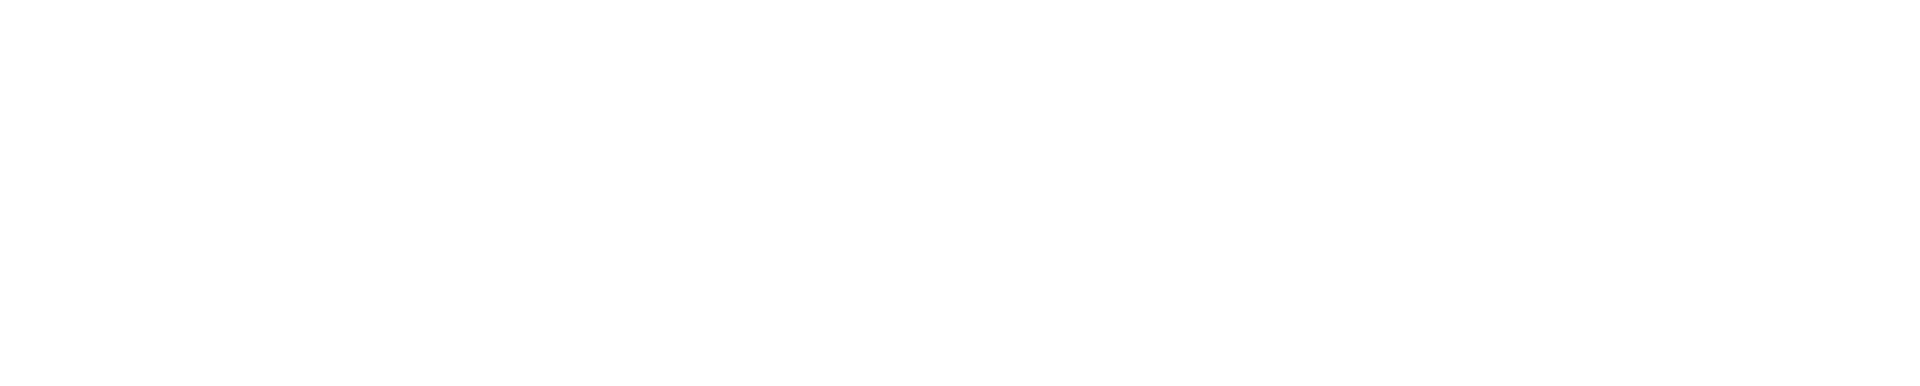

# Desafio Lighthouse — LH Nautical: Notebook de Análise Completa

Este notebook consolida, executa e comenta as 7 questões do desafio numa única peça, como material complementar ao `dashboard/index.html` (entregável obrigatório) e ao `answers/respostas.md` (respostas objetivas por escrito).

**Como este notebook se relaciona com o resto do projeto:** ele não reimplementa a lógica do zero — reaproveita diretamente os arquivos já validados do projeto:
- `sql/q1_orders_eda.sql`, `sql/q4_customer_loyalty.sql`, `sql/q5_calendar_weekday_sales.sql` (executados aqui via DuckDB, célula por célula, com o resultado real de cada consulta).
- `src/q2_generate_schema.py`, `src/q3_load_postgres.py`, `src/q6_demand_forecast.py`, `src/q7_recommender.py` (importados como módulos e executados de verdade — inclusive a Questão 3, que carrega os dados num PostgreSQL local rodando via `docker compose up -d`).

Cada seção termina com a interpretação de negócio, pensada para os três perfis do desafio: **Gabriel Santos** (Tech Lead — clareza e reprodutibilidade: por isso cada resultado aqui é recalculado ao vivo, não colado de uma execução anterior), **Marina Costa** (Gerente — métricas práticas: ticket médio, pior dia de vendas, erro de previsão) e **Sr. Almir** (Fundador — decisão baseada em dado sólido, não em "feeling").


In [1]:
from pathlib import Path
import sys

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATABASE_DIR = PROJECT_ROOT / "database"
SQL_DIR = PROJECT_ROOT / "sql"

con = duckdb.connect()
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

print("Raiz do projeto:", PROJECT_ROOT)
print("CSVs em database/:", len(list(DATABASE_DIR.glob("*.csv"))))


Raiz do projeto: c:\Users\Carlos\Documents\Programação\Desafio-Lighthouse
CSVs em database/: 24


### Função auxiliar: rodar um arquivo `.sql` inteiro e coletar cada resultado

As Questões 1, 4 e 5 já têm suas queries prontas e validadas em `sql/`. Em vez de reescrever as mesmas queries aqui dentro (o que criaria duas fontes de verdade divergentes), esta função lê o `.sql`, separa por `;` e executa cada statement no DuckDB, devolvendo a lista de DataFrames de cada um que retornou linhas (statements como `CREATE TEMP TABLE` não entram na lista). Os `.sql` referenciam os CSVs com caminho relativo `database/...` (pensado para rodar a partir da raiz do projeto) — como o notebook roda a partir de `notebooks/`, a função troca esse prefixo pelo caminho absoluto de `DATABASE_DIR` antes de executar.


In [2]:
def run_sql_statements(sql_text: str) -> list[pd.DataFrame]:
    sql_text = sql_text.replace("'database/", f"'{DATABASE_DIR.as_posix()}/")
    resultados = []
    for stmt in [s.strip() for s in sql_text.split(";") if s.strip()]:
        linhas_uteis = [l for l in stmt.splitlines() if l.strip() and not l.strip().startswith("--")]
        if not linhas_uteis:
            continue
        cur = con.execute(stmt)
        try:
            df = cur.fetchdf()
        except Exception:
            continue
        if len(df):
            resultados.append(df)
    return resultados


---
## Questão 1 — EDA inicial da tabela `orders`

**Premissa obrigatória:** usar apenas `orders.csv`, sem nenhuma limpeza/tratamento — só observar, agregar e descrever. Executado com DuckDB lendo o CSV diretamente (nenhuma tabela intermediária persistida).


In [3]:
q1_resultados = run_sql_statements((SQL_DIR / "q1_orders_eda.sql").read_text(encoding="utf-8"))
visao_geral, stats_total, nulos_por_coluna, dist_status, dist_canal, outliers_iqr = q1_resultados
visao_geral


,total_linhas,total_colunas,data_minima,data_maxima
0,48998,13,01/01/2020 01:19:28,31/12/2026 23:43:09


**48.998 linhas, 13 colunas**, de 01/01/2020 a 31/12/2026. A data máxima já é um sinal de alerta — está bem à frente da data de referência da análise, o que aponta pedidos com data futura na base (tratado na Parte 3, abaixo).


In [4]:
stats_total


,total_min,total_max,total_medio,qtd_nulos_total
0,32.62,"127,262.02","28,704.99",0


Valor médio de `total` = **`R$ 28.704,99`**, sem nenhum nulo na coluna. Mínimo `R$ 32,62`, máximo `R$ 127.262,02` — uma faixa larga, coerente com uma loja que vende de acessório barato a motor de popa.

In [5]:
nulos_por_coluna


,nulos_id,nulos_order_number,nulos_channel,nulos_customer_id,nulos_salesperson_id,nulos_location_id,nulos_status,nulos_subtotal,nulos_discount_amount,nulos_total,nulos_placed_at,nulos_created_at,nulos_updated_at
0,0,0,0,0,24131,0,0,0,0,0,0,0,0


Única coluna com nulos reais é `salesperson_id` (24.131 de 48.998, ~49%). Isso **não é um erro de carga** — é conferir com a distribuição de canal abaixo: pedidos de e-commerce naturalmente não têm vendedor associado.


In [6]:
dist_status


,status,qtd
0,paid,34365
1,confirmed,7335
2,cancelled,4847
3,draft,2451


In [7]:
dist_canal


,channel,qtd
0,ecommerce,34342
1,pos,14656


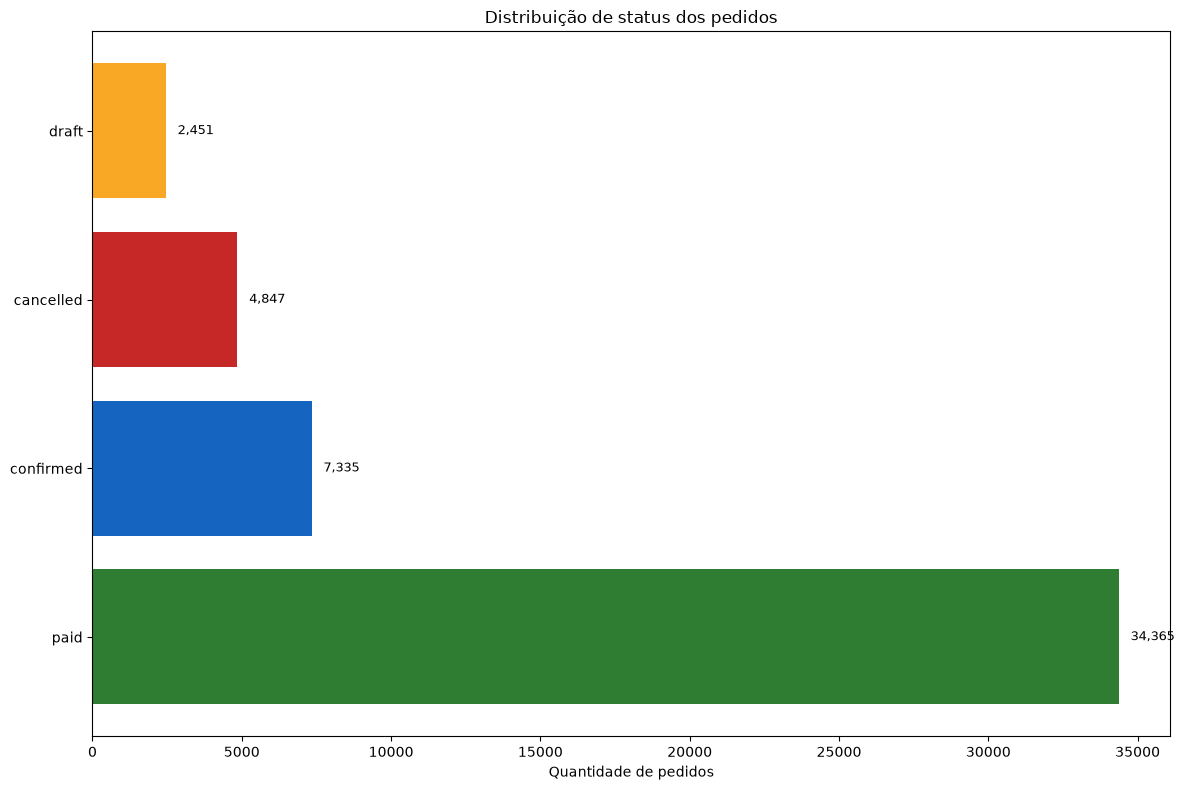

In [28]:
fig, ax = plt.subplots(figsize=(12, 8))
cores = {"paid": "#2e7d32", "confirmed": "#1565c0", "cancelled": "#c62828", "draft": "#f9a825"}
ax.barh(dist_status["status"], dist_status["qtd"], color=[cores[s] for s in dist_status["status"]])
for i, v in enumerate(dist_status["qtd"]):
    ax.text(v + 400, i, f"{v:,}", va="center", fontsize=9)
ax.set_title("Distribuição de status dos pedidos")
ax.set_xlabel("Quantidade de pedidos")
plt.tight_layout()
plt.show()


In [9]:
outliers_iqr


,q1,mediana,q3,iqr,limite_inferior,limite_superior
0,"13,171.24","25,917.84","40,941.88","27,770.65","-28,484.74","82,597.85"


### Questão 1.3 — a tabela está pronta para decisão?

**Parcialmente.** Três achados condicionam qualquer análise feita em cima de `orders` isolada:

1. **`salesperson_id` nulo em ~49% das linhas é esperado**, não um erro — 70% dos pedidos são e-commerce (sem vendedor). Precisa ser documentado antes de qualquer análise de performance por vendedor, senão distorce a média.
2. **Data máxima de `created_at` é 31/12/2026** — vários meses à frente da data de referência da análise. Pedidos com data futura são inconsistentes por definição e precisam ser tratados antes de qualquer série temporal (relevante para a Questão 6).
3. **452 pedidos (0,9%) são outliers pelo critério IQR (1,5×)** em `total`, chegando a `R$ 127.262,02`. Dado que a LH Nautical vende itens de alto ticket (motores, lanchas), isso provavelmente são vendas legítimas — mas não dá pra confirmar sem cruzar com `order_items`/`products`.
4. `status` mistura `paid`, `confirmed`, `cancelled` e `draft` — somar `total` sem filtrar por status (15% da base é `cancelled`+`draft`) mistura receita realizada com receita potencial.

Ver `answers/respostas.md` para a resposta completa dada ao Sr. Almir.


---
## Questão 2 — Geração automática do `schema.sql`

**Tarefa:** ler os CSVs de um diretório e gerar um `CREATE TABLE` por arquivo, com tipo e nulidade **inferidos dos dados**, usando só biblioteca padrão do Python (sem pandas). Código completo em `src/q2_generate_schema.py` — aqui importamos as funções para demonstrar a inferência ao vivo numa tabela real.

A primeira versão desse script era um modelo Python **escrito à mão** (hardcoded) — o que não cumpria o enunciado ("detecta as colunas... a partir do CSV"). Foi reescrito para ler os CSVs de verdade, e no processo dois problemas clássicos de inferência automática de tipo foram encontrados e corrigidos nos dados reais deste desafio:


In [10]:
from q2_generate_schema import (
    read_columns,
    infer_column_type,
    build_create_table,
    has_leading_zero,
)

# 1) zero à esquerda em customers.tax_id -- convertido para NUMERIC apagaria o zero
_, cols = read_columns(DATABASE_DIR / "customers.csv")
tax_id_com_zero = [v for v in cols["tax_id"] if has_leading_zero(v)]
print(f"customers.tax_id: {len(tax_id_com_zero)} de {len(cols['tax_id'])} valores têm zero à esquerda, ex.: {tax_id_com_zero[:3]}")
print("Tipo inferido para tax_id:", infer_column_type(cols["tax_id"]), "(fica VARCHAR, não NUMERIC -- o zero não é perdido)")


customers.tax_id: 223 de 2000 valores têm zero à esquerda, ex.: ['00429721404', '03855975000190', '02524336107']
Tipo inferido para tax_id: VARCHAR(20) (fica VARCHAR, não NUMERIC -- o zero não é perdido)


In [11]:
# 2) quantidade com formato misto (inteiro + decimal na mesma coluna)
_, cols_sm = read_columns(DATABASE_DIR / "stock_movements.csv")
exemplos = [v for v in cols_sm["quantity"] if "." not in v][:2] + [v for v in cols_sm["quantity"] if "." in v][:2]
print("stock_movements.quantity mistura formatos, ex.:", exemplos)
print("Tipo inferido:", infer_column_type(cols_sm["quantity"]), "(NUMERIC cobre os dois formatos sem truncar)")


stock_movements.quantity mistura formatos, ex.: ['-2', '-9', '107.000', '85.000']
Tipo inferido: NUMERIC(8,3) (NUMERIC cobre os dois formatos sem truncar)


In [12]:
# CREATE TABLE gerado de verdade para customers.csv, lendo o arquivo inteiro (não uma amostra)
print(build_create_table(DATABASE_DIR / "customers.csv"))


CREATE TABLE customers (
    id INTEGER PRIMARY KEY,
    person_type VARCHAR(20) NOT NULL,
    legal_name VARCHAR(40) NOT NULL,
    trade_name VARCHAR(40),
    tax_id VARCHAR(20) NOT NULL,
    state_registration VARCHAR(20),
    email VARCHAR(60),
    phone VARCHAR(20),
    is_active BOOLEAN NOT NULL,
    created_at TIMESTAMP NOT NULL,
    updated_at TIMESTAMP NOT NULL
);


O `sql/q2_schema.sql` final (24 tabelas, uma por CSV) é gerado rodando `python src/q2_generate_schema.py` a partir da raiz do projeto — e foi validado executando de ponta a ponta contra um PostgreSQL real (ver Questão 3, abaixo). O schema **não infere chaves estrangeiras** (limitação documentada no próprio cabeçalho do `.sql` gerado): o enunciado pede detecção de colunas, e inferir FK por heurística de nome (ex.: "termina em `_id`") erraria em casos como `stock_movements.reference_id`, que aponta para tabelas diferentes dependendo de `reference_table`.


---
## Questão 3 — Carga dos CSVs em PostgreSQL

**Tarefa:** carregar todos os CSVs respeitando o schema da Questão 2, sem remover nulos nem corrigir caracteres especiais. Código em `src/q3_load_postgres.py`, executado aqui de verdade contra o PostgreSQL local subido por `docker compose up -d` (ver `docker-compose.yml`).


In [13]:
import psycopg2
from q3_load_postgres import DB_PARAMS, LOAD_ORDER, SCHEMA_PATH, apply_schema, load_table, count_csv_rows

conn = psycopg2.connect(**DB_PARAMS)
print(f"Conectado em {DB_PARAMS['dbname']}@{DB_PARAMS['host']}:{DB_PARAMS['port']}")

apply_schema(conn)
print(f"Schema aplicado ({len(LOAD_ORDER)} tabelas recriadas a partir de {SCHEMA_PATH.name}).")


Conectado em lh_nautical@localhost:5432
Schema aplicado (24 tabelas recriadas a partir de q2_schema.sql).


In [14]:
linhas = []
for tabela in LOAD_ORDER:
    csv_rows = count_csv_rows(DATABASE_DIR / f"{tabela}.csv")
    db_rows = load_table(conn, tabela)
    linhas.append({"tabela": tabela, "linhas_csv": csv_rows, "linhas_banco": db_rows, "ok": csv_rows == db_rows})

carga = pd.DataFrame(linhas)
conn.close()
assert carga["ok"].all(), "Divergência de contagem em alguma tabela -- carga incompleta"
print(f"Carga concluída: {carga['ok'].sum()}/{len(carga)} tabelas com contagem batendo 100% com o CSV de origem.")
carga


Carga concluída: 24/24 tabelas com contagem batendo 100% com o CSV de origem.


,tabela,linhas_csv,linhas_banco,ok
0,addresses,3998,3998,True
1,attributes,8,8,True
2,brands,12,12,True
3,categories,14,14,True
4,customers,2000,2000,True
5,employees,15,15,True
6,fiscal_invoices,34365,34365,True
7,goods_receipt_items,4733,4733,True
8,goods_receipts,1548,1548,True
9,locations,6,6,True


- `COPY ... FROM STDIN WITH (FORMAT csv, HEADER true, NULL '')` — `NULL ''` só instrui o Postgres a ler campo vazio do CSV como `NULL`, não é uma limpeza de dado, é a semântica padrão de parsing de CSV.
- Nenhum outro tratamento é aplicado — acentos e caracteres especiais chegam intactos no banco (conferido manualmente: `employees.full_name` = "Maria Luísa Rodrigues").
- Como o schema da Questão 2 não declara FKs, a ordem de carga não depende de "tabela pai antes da filha" — qualquer ordem é segura.


---
## Questão 4 — Clientes fiéis: ticket médio × diversidade de categorias

**Tarefa:** calcular ticket médio e diversidade de categorias por cliente, e identificar os 10 clientes "fiéis" (maior ticket médio entre os que compraram de 13+ categorias distintas). SQL completo em `sql/q4_customer_loyalty.sql`.


In [15]:
q4_resultados = run_sql_statements((SQL_DIR / "q4_customer_loyalty.sql").read_text(encoding="utf-8"))
# os 4 primeiros resultados são as CREATE TEMP TABLE ... AS SELECT (DuckDB devolve a contagem de linhas inseridas);
# os 2 últimos são as consultas finais que realmente respondem a Questão 4.1.
top10_fieis, categoria_mais_vendida = q4_resultados[-2], q4_resultados[-1]
top10_fieis


,customer_id,faturamento_total,frequencia,ticket_medio,diversidade_categorias
0,22,"1,087,838.44",26,"41,839.94",14
1,1477,"916,262.58",22,"41,648.30",14
2,929,"1,082,775.89",26,"41,645.23",14
3,1116,"655,737.20",16,"40,983.58",14
4,1691,"815,471.30",20,"40,773.56",14
5,774,"726,127.99",18,"40,340.44",14
6,1470,"1,040,553.09",26,"40,021.27",14
7,1599,"997,616.46",25,"39,904.66",14
8,965,"677,297.78",17,"39,841.05",14
9,1722,"1,146,455.22",29,"39,532.94",14


Os 10 clientes fiéis têm todos exatamente **14 categorias distintas** (o máximo observado na base) — o filtro de elite (≥13) já isola naturalmente o topo da distribuição de diversidade antes mesmo de olhar o ticket médio.

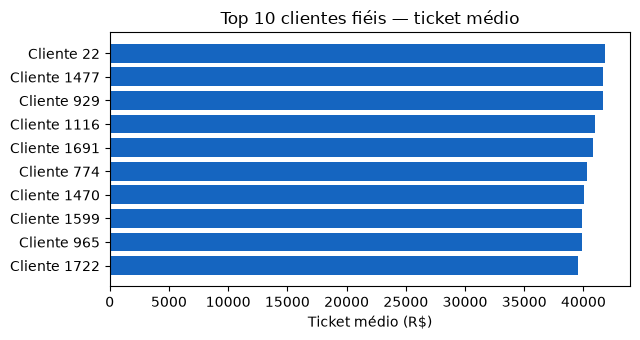

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.barh([f"Cliente {c}" for c in top10_fieis["customer_id"]][::-1], top10_fieis["ticket_medio"][::-1], color="#1565c0")
ax.set_xlabel("Ticket médio (R$)")
ax.set_title("Top 10 clientes fiéis — ticket médio")
plt.tight_layout()
plt.show()


In [17]:
categoria_mais_vendida.head(5)


,category_id,category_name,quantidade_total_itens
0,8,Hélices,492.00
1,3,Coletes Salva-Vidas,393.00
2,5,Eletrônica Náutica,392.00
3,7,Âncoras,387.00
4,10,Iluminação,333.00


**Hélices** é a categoria com maior volume de itens (492) entre os 10 clientes fiéis, à frente de Coletes Salva-Vidas (393) e Eletrônica Náutica (392).

---
## Questão 5 — Dimensão de calendário: pior dia da semana (lojas físicas)

**Cenário:** um estagiário fez `GROUP BY` direto em `orders` e concluiu que Domingo era ótimo — mas dias em que a loja abriu e vendeu **zero** simplesmente não existem na tabela de vendas, então foram ignorados no cálculo, inflando a média. A correção é construir uma dimensão de calendário (todo dia do período) e tratar ausência de venda como `R$ 0,00`. SQL completo em `sql/q5_calendar_weekday_sales.sql`.


In [18]:
q5_resultado = run_sql_statements((SQL_DIR / "q5_calendar_weekday_sales.sql").read_text(encoding="utf-8"))
media_por_dia = q5_resultado[0]
media_por_dia


,dow_num,dia_semana,qtd_dias_no_periodo,dias_sem_venda,soma_vendas,media_vendas_dia
0,4,Quinta-feira,366,20.00,"57,518,480.61","157,154.32"
1,0,Domingo,365,12.00,"57,529,887.95","157,616.13"
2,1,Segunda-feira,365,7.00,"57,758,021.43","158,241.15"
3,6,Sábado,365,11.00,"60,173,268.58","164,858.27"
4,2,Terça-feira,365,8.00,"60,633,373.26","166,118.83"
5,5,Sexta-feira,365,10.00,"62,120,694.25","170,193.68"
6,3,Quarta-feira,366,10.00,"63,539,589.22","173,605.44"


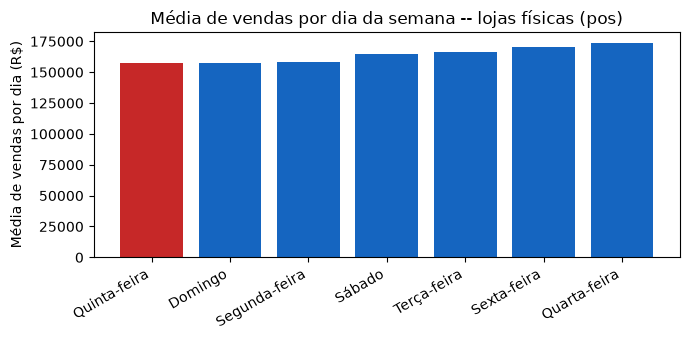

In [19]:
fig, ax = plt.subplots(figsize=(7, 3.5))
pior = media_por_dia["media_vendas_dia"].idxmin()
cores = ["#1565c0" if i != pior else "#c62828" for i in media_por_dia.index]
ax.bar(media_por_dia["dia_semana"], media_por_dia["media_vendas_dia"], color=cores)
ax.set_ylabel("Média de vendas por dia (R$)")
ax.set_title("Média de vendas por dia da semana -- lojas físicas (pos)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


**Pior dia: Quinta-feira**, com a menor média de vendas — mas tecnicamente empatado com Domingo e Segunda-feira (diferença menor que 1% entre os três). Antes de fechar a loja num dia específico, vale olhar a variância diária desses três dias, não só a média pontual.

### Reproduzindo o erro do estagiário, para comparação


In [20]:
metodo_estagiario = con.execute(f"""
    SELECT
        CASE CAST(strftime(CAST(placed_at AS DATE), '%w') AS INTEGER)
            WHEN 0 THEN 'Domingo' WHEN 1 THEN 'Segunda-feira' WHEN 2 THEN 'Terça-feira'
            WHEN 3 THEN 'Quarta-feira' WHEN 4 THEN 'Quinta-feira' WHEN 5 THEN 'Sexta-feira'
            WHEN 6 THEN 'Sábado' END AS dia_semana,
        COUNT(*) AS dias_com_venda,
        ROUND(AVG(valor_venda), 2) AS media_ingenua
    FROM (
        SELECT CAST(placed_at AS DATE) AS placed_at, SUM(total) AS valor_venda
        FROM read_csv_auto('{DATABASE_DIR.as_posix()}/orders.csv')
        WHERE channel = 'pos'
        GROUP BY CAST(placed_at AS DATE)
    )
    GROUP BY 1 ORDER BY media_ingenua ASC
""").fetchdf()
metodo_estagiario


,dia_semana,dias_com_venda,media_ingenua
0,Segunda-feira,358,"161,335.26"
1,Domingo,353,"162,974.19"
2,Quinta-feira,346,"166,238.38"
3,Terça-feira,357,"169,841.38"
4,Sábado,354,"169,980.98"
5,Sexta-feira,355,"174,987.87"
6,Quarta-feira,356,"178,481.99"


O `GROUP BY` direto (sem dimensão de calendário) aponta **Segunda-feira** como "pior" — e esconde Quinta-feira do radar completamente, porque o denominador (`COUNT` de dias *com* venda) já exclui os dias vazios por construção, inflando artificialmente a média nos dias com mais buracos.


---
## Questão 6 — Previsão de demanda: baseline de média móvel ("Bússola de Bordo 702")

**Nota de qualidade de dados:** `products.csv` tem duas linhas com o nome exato "Bússola de Bordo 702" (id 74 e id 240) — colisão de nome nos dados sintéticos, não uma variação de SKU. Usamos o **id 74**: o id 240 só "nasce" no catálogo em junho/2026, depois de todo o período de treino/teste deste modelo (até 31/03/2026).

Código completo em `src/q6_demand_forecast.py`, importado aqui e executado ao vivo — incluindo uma comparação extra com um modelo naive sazonal, feita para testar empiricamente se um modelo alternativo simples teria performado melhor.


In [21]:
from q6_demand_forecast import (
    load_unified_dataset,
    monthly_quantity,
    moving_average_baseline,
    seasonal_naive_baseline,
    mean_absolute_error,
    TEST_MONTHS,
    TRAIN_END,
    PRODUCT_NAME,
)

df_q6 = load_unified_dataset()
mensal = monthly_quantity(df_q6)
print(f"Produto: {PRODUCT_NAME}")
print(f"Histórico: {mensal.index.min()} a {mensal.index.max()} ({len(mensal)} meses)")
print(f"Treino até: {TRAIN_END} | Teste: {list(TEST_MONTHS)}")


Produto: Bússola de Bordo 702
Histórico: 2020-01 a 2026-12 (77 meses)
Treino até: 2025-12 | Teste: [Period('2026-01', 'M'), Period('2026-02', 'M'), Period('2026-03', 'M')]


In [22]:
real = mensal.reindex(TEST_MONTHS).fillna(0)
previsto_mm = moving_average_baseline(mensal, TEST_MONTHS)
previsto_naive = seasonal_naive_baseline(mensal, TEST_MONTHS)

comparativo_q6 = pd.DataFrame({
    "real": real,
    "media_movel_3m": previsto_mm.round(2),
    "naive_sazonal": previsto_naive.round(2),
})
comparativo_q6["erro_media_movel"] = (comparativo_q6["real"] - comparativo_q6["media_movel_3m"]).abs().round(2)
comparativo_q6["erro_naive_sazonal"] = (comparativo_q6["real"] - comparativo_q6["naive_sazonal"]).abs().round(2)

mae_mm = mean_absolute_error(real, previsto_mm)
mae_naive = mean_absolute_error(real, previsto_naive)

print(f"MAE média móvel 3m:  {mae_mm:.2f}")
print(f"MAE naive sazonal:   {mae_naive:.2f}")
comparativo_q6


MAE média móvel 3m:  16.44
MAE naive sazonal:   30.00


,real,media_movel_3m,naive_sazonal,erro_media_movel,erro_naive_sazonal
2026-01,69,25.33,25,43.67,44
2026-02,42,39.67,21,2.33,21
2026-03,45,41.67,70,3.33,25


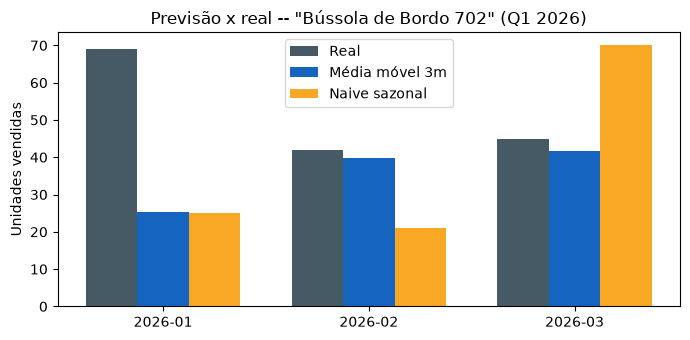

In [23]:
fig, ax = plt.subplots(figsize=(7, 3.5))
x = range(len(comparativo_q6))
largura = 0.25
ax.bar([i - largura for i in x], comparativo_q6["real"], largura, label="Real", color="#455a64")
ax.bar(x, comparativo_q6["media_movel_3m"], largura, label="Média móvel 3m", color="#1565c0")
ax.bar([i + largura for i in x], comparativo_q6["naive_sazonal"], largura, label="Naive sazonal", color="#f9a825")
ax.set_xticks(list(x))
ax.set_xticklabels([str(m) for m in comparativo_q6.index])
ax.set_ylabel("Unidades vendidas")
ax.set_title(f'Previsão x real -- "{PRODUCT_NAME}" (Q1 2026)')
ax.legend()
plt.tight_layout()
plt.show()


**5a. O baseline é adequado?** Parcialmente. Fevereiro e março saem bem (erro pequeno), mas em janeiro o modelo erra 63% — dezembro/2025 foi um mês fraco (14 un.) e a média móvel arrasta esse valor baixo para janeiro, exatamente o mês em que a demanda historicamente dispara.

**A comparação com o naive sazonal reforça o diagnóstico em vez de resolvê-lo:** um modelo que apostasse no "mesmo mês do ano anterior" saiu **pior** (MAE quase o dobro) — os janeiros de 2020 a 2025 nunca chegaram perto do salto de 2026, então nem o padrão sazonal histórico previa esse pico. O problema não é só "a média móvel não vê sazonalidade": é que a demanda de jan/2026 quebrou o próprio padrão sazonal do produto.

**5b. Limitação:** média móvel é um indicador **defasado** — só reage a uma mudança de patamar depois que ela já entrou na janela. Um modelo mais robusto combinaria tendência recente **e** sazonalidade suavizada por múltiplos anos (ex.: Holt-Winters), não um único ano de referência como o naive sazonal testado aqui.


---
## Questão 7 — Recomendação: "quem comprou isso, também levou..."

**Tarefa:** matriz de interação Usuário × Produto binária (comprou/não comprou, ignorando quantidade), similaridade de cosseno produto × produto, e ranking dos 5 produtos mais similares a "Motor de Popa 1949". Código completo em `src/q7_recommender.py`.


In [24]:
from q7_recommender import (
    load_customer_product_purchases,
    build_user_item_matrix,
    compute_product_similarity,
    top_similar_products,
    REFERENCE_PRODUCT_NAME,
    TOP_N,
)

compras = load_customer_product_purchases()
mapa_nomes = compras.drop_duplicates("product_id").set_index("product_id")["name"].to_dict()
ref_id = int(compras.loc[compras["name"] == REFERENCE_PRODUCT_NAME, "product_id"].iloc[0])

matriz = build_user_item_matrix(compras)
print(f"Matriz usuário-item: {matriz.shape[0]} clientes x {matriz.shape[1]} produtos")

similaridade = compute_product_similarity(matriz)
ranking_q7 = top_similar_products(similaridade, mapa_nomes, ref_id, TOP_N)
ranking_q7


Matriz usuário-item: 2000 clientes x 500 produtos


,product_id,product_name,similaridade_cosseno
0,389,Motor de Popa 5331,0.26
1,295,Cabo Náutico 2105,0.26
2,75,Vela Mestra 1913,0.26
3,337,Cabo Náutico 9048,0.24
4,55,GPS Plotter 6249,0.24


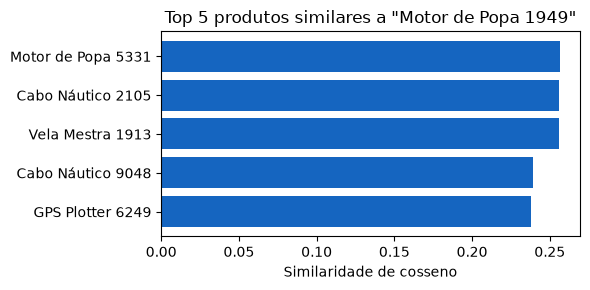

In [25]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(ranking_q7["product_name"][::-1], ranking_q7["similaridade_cosseno"][::-1], color="#1565c0")
ax.set_xlabel("Similaridade de cosseno")
ax.set_title(f'Top {TOP_N} produtos similares a "{REFERENCE_PRODUCT_NAME}"')
plt.tight_layout()
plt.show()


Scores modestos (0,24–0,26) em toda a base — sintoma de uma base densa (~271 compradores/produto em média): quando muitos produtos são comprados por muitos clientes diferentes, o sinal de afinidade genuína se dilui em ruído estatístico. O método também sofre de **cold-start**: um produto novo, sem histórico, tem vetor todo-zero e não pode ser comparado a nada.


---
## Conclusão executiva

- **Para o Gabriel Santos (Tech Lead):** todo resultado deste notebook foi recalculado ao vivo a partir dos CSVs e do PostgreSQL local, célula por célula — não há número colado de uma execução anterior. O código-fonte único de cada questão vive em `sql/` e `src/`; este notebook só importa e executa, evitando duas versões divergentes da mesma lógica.
- **Para a Marina Costa (Gerente de Negócios):** o cliente 22 é o mais fiel (ticket médio `R$ 41.839,94`, 14 categorias distintas); Quinta-feira é o pior dia de vendas nas lojas físicas; o modelo de previsão erra 63% no mês de pico (janeiro) mesmo depois de testar um segundo modelo — ou seja, comprar estoque para o verão baseado só nesse baseline é arriscado.
- **Para o Sr. Almir (Fundador):** a base de `orders` tem uma inconsistência real (datas de pedido até dezembro/2026, no futuro) e um nulo estrutural (`salesperson_id`) que precisam ser tratados antes de qualquer decisão — mas isso não invalida a análise, só delimita onde ela é confiável. Nenhuma conclusão aqui vem de "feeling": cada número tem a query ou o código que o gerou, reproduzível por qualquer pessoa que rode este notebook.

Ver `dashboard/index.html` para a visão consolidada interativa, e `answers/respostas.md` para as respostas objetivas completas de cada questão.
